In [1]:
#################
## BIBILIOTEKE ##
#################
import pandas as pd
import csv
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys

import tweetnlp

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
import transformers.utils.import_utils

from datasets import Dataset

from scipy.special import softmax

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_fscore_support, classification_report, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn

/home/rastkol/.pyenv/versions/rastko/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-15 22:03:03,832	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-07-15 22:03:04,977	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
############################
##   UČITAVANJE PODATAKA  ##
############################
data = pd.read_csv('Dataset_to_upload.csv', sep=';')

PROBNA AKTIVACIJA MODELA
------------------------

In [ ]:
######################################
## model jedan                      ##
## twitter-roberta-base-hate-latest ##
######################################

###!!!!!!!!!!!!!!!!!!!!!!###
## OVAJ MODEL IMA PROBLEM ##
###!!!!!!!!!!!!!!!!!!!!!!!##

model = tweetnlp.Classifier("cardiffnlp/twitter-roberta-base-hate-latest")
model.predict('I love everybody :)')

In [3]:
###############################
## model dva                 ##
## twitter-roberta-base-hate ##
###############################

def makeModel(taskType):

    #***********************************
    # Definisanje naziva modela na Hub-u
    model_name = f"cardiffnlp/twitter-roberta-base-{taskType}"
    #device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    #***********************************
    # Učitavanje labela sa GitHub-a
    mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{taskType}/mapping.txt"
    try:
        with urllib.request.urlopen(mapping_link) as f:
            html = f.read().decode('utf-8').split("\n")
            csvreader = csv.reader(html, delimiter='\t')
            labels = [row[1] for row in csvreader if len(row) > 1]
    except Exception as e:
        print(f"Upozorenje: Neuspešno učitavanje labela: {e}")
        labels = []

    #***********************************
    # Učitavanje tokenizatora i modela direktno sa interneta/keša
    tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=False, force_download=True)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, local_files_only=False, force_download=True)

    #***********************************
    # Dodatno
    #model.to(device)
    #model.eval()

    return tokenizer, labels, model

/home/rastkol/.pyenv/versions/rastko/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
############################################
## Funkcija za predprocesiranje komentara ##
############################################

def preprocess(text):
    new_text = []
    for t in text.split(" "):
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

In [45]:
##################################
## Funkcija koja aktivira model ##
##################################

def activateModel(data, tokenizer, model):

    #****************************************
    # mod za evaluaciju
    model.eval()
    device = next(model.parameters()).device


    dataArr = np.array(data.Sample)
    result = []
    i = 0

    for txt in dataArr:

        text = preprocess(txt)
        encoded_input = tokenizer(text, return_tensors='pt',padding=True, truncation=True, max_length=512).to(device) # tokenizacija

        with torch.no_grad():
            output = model(**encoded_input)
            scores = output[0][0].detach().numpy()

        scores = softmax(scores)
        result.append(np.argmax(scores))

        i += 1
    return result

In [6]:
#############################################
## Učitavanje: tokenizator, labele i model ##
#############################################
tokenizerH, labelsH, modelH = makeModel('hate')
tokenizerO, labelsO, modelO = makeModel('offensive')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 21321.58it/s]


In [7]:
###########################################
## Provera ispravnosti rada tokenizatora ##
###########################################

encoded_input1 = tokenizerH("Your runway name should be Methany", return_tensors='pt')
encoded_input2 = tokenizerH("Just wait till you see her deep fried yeti cankles, knee deep inside herself.", return_tensors='pt')
print(encoded_input1.data['input_ids'])
print(encoded_input2.data['input_ids'])

tensor([[    0, 12861, 10996,   766,   197,    28, 28190,  3785,     2]])
tensor([[    0,  6785,  2067,  6612,    47,   192,    69,  1844, 16708,   648,
           118,    64,   330,  1634,     6,  4117,  1844,  1025,  2864,     4,
             2]])


In [71]:
#######################
## Aktivacija modela ##
#######################

resultH = activateModel(data, tokenizerH, modelH)
resultO = activateModel(data, tokenizerO, modelO)

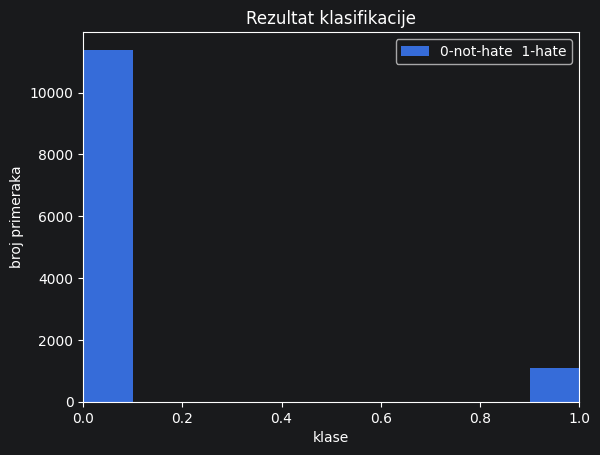

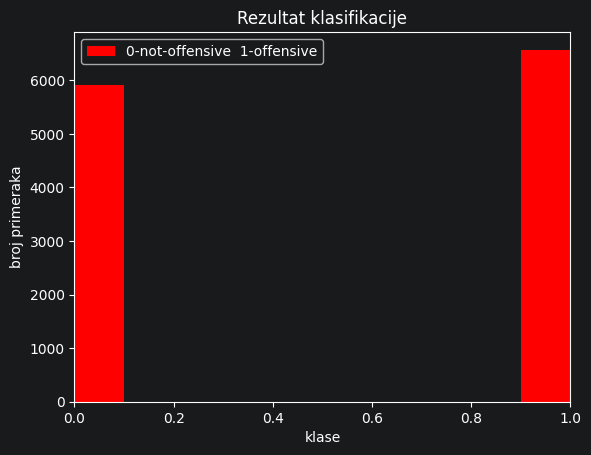

In [74]:
############################
## Rezultat klasifikacije ##
############################

plt.figure()
plt.title("Rezultat klasifikacije")
plt.hist(resultH, label=f"0-{labelsH[0]}  1-{labelsH[1]}")
plt.xlim([0,1])
plt.xlabel("klase")
plt.ylabel("broj primeraka")
plt.legend()
plt.show()

plt.figure()
plt.title("Rezultat klasifikacije")
plt.hist(resultO, label=f"0-{labelsO[0]}  1-{labelsO[1]}",color="red")
plt.xlim([0,1])
plt.xlabel("klase")
plt.ylabel("broj primeraka")
plt.legend()
plt.show()

In [5]:
################################################
## Modifikovana funkcija za aktivaciju modela ##
################################################

def activateModelTwo(data, tokenizer, label, model, taskType):

    result = pd.DataFrame(columns=['id','txt_sample','original_label',f'pred_label_{taskType}',f'prob_{taskType}'])

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()

    device = next(model.parameters()).device

    i = 0
    for row in data.itertuples():
        id = i
        try:
            originalLabel = row.Majority_label
        except (AttributeError, KeyError):
            originalLabel = row.original_label

        try:
            sample = row.Sample
        except(AttributeError, KeyError):
            sample = row.txt_sample

        text = preprocess(sample)
        encoded_input = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512).to(device)

        with torch.no_grad():
            output = model(**encoded_input)
            logits = output.logits.squeeze(0).cpu().numpy()

        scores = softmax(logits)
        prob = scores[1]
        predLabel = label[np.argmax(scores)]

        i += 1

        result.loc[id] = [id, sample, originalLabel, predLabel, prob]
    return result


In [27]:
########################
## Data frame za hate ##
########################

dfHate = activateModelTwo(data,tokenizerH,labelsH,modelH,'hate')

In [28]:
#############################
## Data frame za offensive ##
#############################

dfOffensive = activateModelTwo(data,tokenizerO,labelsO,modelO,'offensive')

In [29]:
##########################
## Rezultat u csv fajlu ##
##########################

dfPredikcijeCardiffModela = pd.merge(dfHate, dfOffensive, on=['id','txt_sample','original_label'])
dfPredikcijeCardiffModela.to_csv('predikcije_cardiff_modela.csv', index=False)

In [18]:
#####################
## Ispravni podaci ##
#####################

dfPredikcijeCardiffModela = pd.read_csv('predikcije_cardiff_modela.csv')

dfTrueHate = dfPredikcijeCardiffModela[['id','original_label']].copy()
dfTrueOffensive = dfPredikcijeCardiffModela[['id','original_label']].copy()

nonHateLabels = ["Normal", "Trolling", "Profanity"]
dfTrueHate['original_label'] = np.where(dfTrueHate['original_label'].isin(nonHateLabels), "not-hate", "hate")

nonOffensiveLabels = ["Normal", "Trolling"]
dfTrueOffensive['original_label'] = np.where(dfTrueOffensive['original_label'].isin(nonOffensiveLabels), "not-offensive", "offensive")

In [2]:
#########################
## Funkcija za metrike ##
#########################

def modelMetrics(TN, FP, FN, TP):

    print(f'True negative: {TN}')
    print(f'False positive: {FP}')
    print(f'False negative: {FN}')
    print(f'True positive: {TP}')

    # Accuracy
    ACC = (TP + TN) / (TN + FP + FN + TP)
    print(f'Accuracy: {ACC:.3f}')

    # Precision
    P = TP / (TP + FP) if (TP + FP) != 0 else 0
    print(f'Precision: {P:.3f}')

    # Recall
    R = TP / (TP + FN) if (TP + FN) != 0 else 0
    print(f'Recall: {R:.3f}')

    # Specificity
    S = TN / (TN + FP) if (TN + FP) != 0 else 0
    print(f'Specificity: {S:.3f}')

    # F1 - score
    F1 = 2 * P * R / (P + R) if (P + R) != 0 else 0
    print(f'F1 - score: {F1:.3f}')

    # Balanced accuracy
    BA = (R + S) / 2
    print(f'Balanced accuracy: {BA:.3f}')

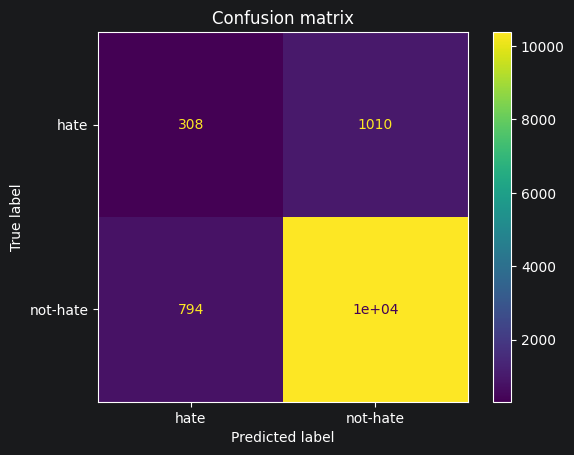

True negative: 308
False positive: 1010
False negative: 794
True positive: 10378
Accuracy: 0.856
Precision: 0.911
Recall: 0.929
Specificity: 0.234
F1 - score: 0.920
Balanced accuracy: 0.581


In [7]:
####################################
## Analiza tačnosti modela - HATE ##
####################################

cmHate = confusion_matrix(dfTrueHate.original_label, dfPredikcijeCardiffModela.pred_label_hate)
TN_h,FP_h,FN_h,TP_h = cmHate.ravel()

ConfusionMatrixDisplay(confusion_matrix=cmHate,display_labels=sorted(dfTrueHate.original_label.unique())).plot()
plt.title('Confusion matrix')
plt.show()

modelMetrics(TN_h,FP_h,FN_h,TP_h)

In [19]:

target_ids = [1562, 1358, 807, 1159, 515, 1148, 155, 390, 1751, 1487, 753, 1657, 268, 889]

df_merged = pd.merge(
    dfTrueHate[['id', 'original_label']],
    dfPredikcijeCardiffModela[['id', 'pred_label_hate']],
    on='id'
)
df_filtered = df_merged[df_merged['id'].isin(target_ids)]

print("=" * 80)
print(" HATE CLASS PREDICTION EVALUATION FOR TARGET IDs")
print("=" * 80)

for _, row in df_filtered.iterrows():
    current_id = row['id']
    true_lbl = row['original_label']
    pred_lbl = row['pred_label_hate']

    # Određivanje statusa predikcije u odnosu na 'hate' kao pozitivnu klasu
    if true_lbl == 'hate' and pred_lbl == 'hate':
        status = "Correctly Predicted (True Positive - Hate)"
    elif true_lbl == 'not-hate' and pred_lbl == 'not-hate':
        status = "Correctly Predicted (True Negative - Not Hate)"
    elif true_lbl == 'not-hate' and pred_lbl == 'hate':
        status = "Incorrectly Predicted (False Positive - Model guessed Hate, but it's Not Hate)"
    elif true_lbl == 'hate' and pred_lbl == 'not-hate':
        status = "Incorrectly Predicted (False Negative - Model missed Hate)"
    else:
        status = "Unknown combination"

    print(f"ID: {current_id:<5} | True Label: {true_lbl:<10} | Predicted Label: {pred_lbl:<10} | Status: {status}")

print("=" * 80)

 HATE CLASS PREDICTION EVALUATION FOR TARGET IDs
ID: 155   | True Label: not-hate   | Predicted Label: not-hate   | Status: Correctly Predicted (True Negative - Not Hate)
ID: 268   | True Label: not-hate   | Predicted Label: not-hate   | Status: Correctly Predicted (True Negative - Not Hate)
ID: 390   | True Label: not-hate   | Predicted Label: not-hate   | Status: Correctly Predicted (True Negative - Not Hate)
ID: 515   | True Label: not-hate   | Predicted Label: not-hate   | Status: Correctly Predicted (True Negative - Not Hate)
ID: 753   | True Label: not-hate   | Predicted Label: not-hate   | Status: Correctly Predicted (True Negative - Not Hate)
ID: 807   | True Label: not-hate   | Predicted Label: not-hate   | Status: Correctly Predicted (True Negative - Not Hate)
ID: 889   | True Label: not-hate   | Predicted Label: hate       | Status: Incorrectly Predicted (False Positive - Model guessed Hate, but it's Not Hate)
ID: 1148  | True Label: not-hate   | Predicted Label: not-hate   

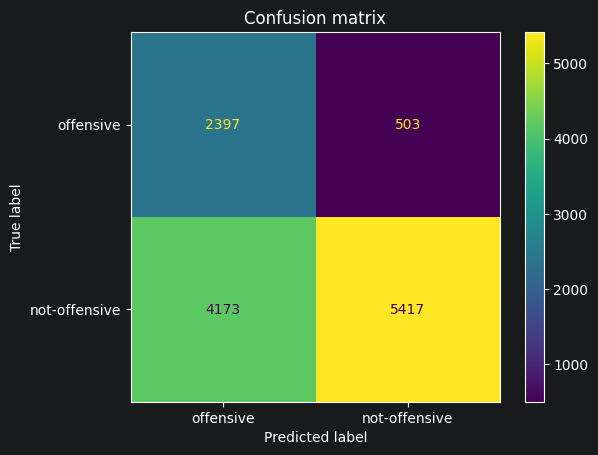

True negative: 5417
False positive: 4173
False negative: 503
True positive: 2397
Accuracy: 0.626
Precision: 0.365
Recall: 0.827
Specificity: 0.565
F1 - score: 0.506
Balanced accuracy: 0.696


In [11]:
#########################################
## Analiza tacnosti modela - OFFENSIVE ##
#########################################

# Stavljamo 'offensive' na PRVO mesto (indeks 0 - gore levo)
target_labels = ['offensive', 'not-offensive']

cmOffensive = confusion_matrix(
    dfTrueOffensive.original_label,
    dfPredikcijeCardiffModela.pred_label_offensive,
    labels=target_labels
)


TP_o = cmOffensive[0, 0]
FN_o = cmOffensive[0, 1]
FP_o = cmOffensive[1, 0]
TN_o = cmOffensive[1, 1]

disp = ConfusionMatrixDisplay(confusion_matrix=cmOffensive, display_labels=target_labels)
disp.plot()

plt.title('Confusion matrix')
plt.show()

modelMetrics(TN_o, FP_o, FN_o, TP_o)

**Zaključak analize (ovu mogu dopuniti kad budem pakovao prezentacija)**
- ovde je fokus na razliku u ucinku i identifikaciji pozitivnih/negativnih primera

- dataset nije izbalansiran, to ima posledicu na metrike

- primeri fasle positive i flase negative situacija za offense i hate

### Fine-tuning

binary classification models

#### hate task

Derogatory + Hate Speech = hate

Normal + Trolling + Profanity = not-hate

### offensive task

Profanity + Derogatory + Hate Speech = offensive;
Normal + Trolling = not-offensive

#### data preparation

label_hate
label_offensive

data split: 70-15-15

### resources

16gb vram free

max_length = 128
batch_size = 16
fp16 = True


In [20]:
target_ids = [646, 1071, 1474, 213, 1363, 1800, 945, 1476, 541, 1204, 1203, 1201, 1451, 744]


df_merged = pd.merge(
    dfTrueOffensive[['id', 'original_label']],
    dfPredikcijeCardiffModela[['id', 'pred_label_offensive']],
    on='id'
)
df_filtered = df_merged[df_merged['id'].isin(target_ids)]

print("=" * 95)
print(" OFFENSIVE CLASS PREDICTION EVALUATION FOR TARGET IDs")
print("=" * 95)

for _, row in df_filtered.iterrows():
    current_id = row['id']
    true_lbl = row['original_label']
    pred_lbl = row['pred_label_offensive']

    if true_lbl == 'offensive' and pred_lbl == 'offensive':
        status = "Correctly Predicted (True Positive - Offensive)"
    elif true_lbl == 'not-offensive' and pred_lbl == 'not-offensive':
        status = "Correctly Predicted (True Negative - Not Offensive)"
    elif true_lbl == 'not-offensive' and pred_lbl == 'offensive':
        status = "Incorrectly Predicted (False Positive - Model guessed Offensive, but it's Not Offensive)"
    elif true_lbl == 'offensive' and pred_lbl == 'not-offensive':
        status = "Incorrectly Predicted (False Negative - Model missed Offensive)"
    else:
        status = "Unknown combination"

    print(f"ID: {current_id:<5} | True Label: {true_lbl:<14} | Predicted Label: {pred_lbl:<14} | Status: {status}")

print("=" * 95)

 OFFENSIVE CLASS PREDICTION EVALUATION FOR TARGET IDs
ID: 213   | True Label: not-offensive  | Predicted Label: not-offensive  | Status: Correctly Predicted (True Negative - Not Offensive)
ID: 541   | True Label: not-offensive  | Predicted Label: not-offensive  | Status: Correctly Predicted (True Negative - Not Offensive)
ID: 646   | True Label: not-offensive  | Predicted Label: not-offensive  | Status: Correctly Predicted (True Negative - Not Offensive)
ID: 744   | True Label: not-offensive  | Predicted Label: not-offensive  | Status: Correctly Predicted (True Negative - Not Offensive)
ID: 945   | True Label: not-offensive  | Predicted Label: offensive      | Status: Incorrectly Predicted (False Positive - Model guessed Offensive, but it's Not Offensive)
ID: 1071  | True Label: offensive      | Predicted Label: offensive      | Status: Correctly Predicted (True Positive - Offensive)
ID: 1201  | True Label: not-offensive  | Predicted Label: offensive      | Status: Incorrectly Predicte

------------------------------------
**Fine-tune roberta (hate i offensive modeli)**
------------------------------------


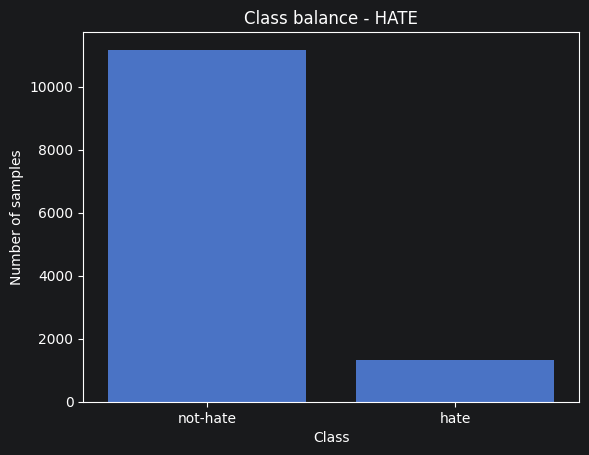

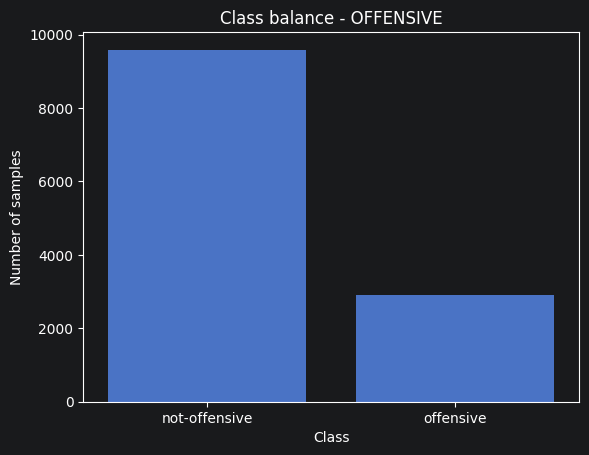

In [1]:
#####################################
## Priprema podataka               ##
## Pregled balansiranosti podatata ##
#####################################

dfPredikcijeCardiffModela = pd.read_csv('predikcije_cardiff_modela.csv')

hateData = dfPredikcijeCardiffModela[['id','txt_sample','original_label']].copy()
nonHateLabels = ["Normal", "Trolling", "Profanity"]
hateData['original_label'] = np.where(hateData['original_label'].isin(nonHateLabels), "not-hate", "hate")

offensiveData = dfPredikcijeCardiffModela[['id','txt_sample','original_label']].copy()
nonOffensiveLabels = ["Normal", "Trolling"]
offensiveData['original_label'] = np.where(offensiveData['original_label'].isin(nonOffensiveLabels),"not-offensive", "offensive")

#************************************
# vizuelizacija

plt.figure()
sns.countplot(data=hateData, x='original_label')
plt.title('Class balance - HATE')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.show()

plt.figure()
sns.countplot(data=offensiveData, x='original_label')
plt.title('Class balance - OFFENSIVE')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.show()


Primećujemo visoku nebalansiranost klasa.
Možemo izvršiti fine-tune sa ovakvim podacima, međutim poželjno je da izrvšimo neki od postupaka balansiranja.


In [3]:
############################
# Preprocesiranje dataseta #
############################

# Uklanjanje NaN (praznih) vrednosti iz tekstualne kolone
# Čišćenje nevidljivih razmaka na početku i kraju teksta (.strip())
# Uklanjanje egzaktnih duplikata (isti tekst i ista klasa/labela)
# Zadržavamo samo prvo pojavljivanje tog reda ('first')
# Pronalaženje i uklanjanje konfliktnih labela (isti tekst sa različitim klasama)
# Brojimo koliko jedinstvenih klasa/labela ima svaki pojedinačni tekst
# Zadržavamo samo one redove čiji tekst NIJE na listi konfliktnih tekstova


def preprocessDataset(df, textColumn='txt_sample', labelColumn='original_label'):
    initialCount = len(df)
    print(f"Initial number of rows: {initialCount}")

    df = df.dropna(subset=[textColumn]).copy()
    df[textColumn] = df[textColumn].astype(str).str.strip()
    df = df[df[textColumn] != ""]


    df = df.drop_duplicates(subset=[textColumn, labelColumn], keep='first')
    countAfterExact = len(df)
    print(f"After removing exact duplicates: {countAfterExact} (Removed: {initialCount - countAfterExact})")

    labelsPerText = df.groupby(textColumn)[labelColumn].nunique()
    conflictingTexts = labelsPerText[labelsPerText > 1].index

    dfFinal = df[~df[textColumn].isin(conflictingTexts)].copy()

    finalCount = len(dfFinal)
    print(f"After removing conflicting samples: {finalCount} (Conflicting removed: {countAfterExact - finalCount})")
    print(f"--- Total retained: {finalCount} rows ({round((finalCount / initialCount) * 100, 2)}% of original dataset) ---")

    return dfFinal




In [24]:
#########################################
## Funkcija za analizu podele dataseta ##
#########################################
def writeStats(train, test, val, taskType):
    print(taskType)
    print(f"Number of training samples: {len(train)}, not-{taskType}: {(train == f'not-{taskType}').sum()}, {taskType}: {(train == taskType).sum()}")

    print(f"Numer of validation samples: {len(val)}, not-{taskType}: {(val == f'not-{taskType}').sum()}, {taskType}: {(val == taskType).sum()}")

    print(f"Number of testing samples: {len(test)}, not-{taskType}: {(test == f'not-{taskType}').sum()}, {taskType}: {(test == taskType).sum()}")

In [36]:
#######################
# Predobrada podataka #
#######################

print("HATE")
hateDataFinal = preprocessDataset(hateData)
print()
print("OFFENSIVE")
offensiveDataFinal = preprocessDataset(offensiveData)

HATE
Initial number of rows: 12490
After removing exact duplicates: 12238 (Removed: 252)
After removing conflicting samples: 12162 (Conflicting removed: 76)
--- Total retained: 12162 rows (97.37% of original dataset) ---

OFFENSIVE
Initial number of rows: 12490
After removing exact duplicates: 12252 (Removed: 238)
After removing conflicting samples: 12148 (Conflicting removed: 104)
--- Total retained: 12148 rows (97.26% of original dataset) ---


In [37]:
################################################
## Podela podataka na trening\validacija\test ##
## Odnos podele: 70\15\15                     ##
################################################
randomState = 45

hateTrainSample, hateTestSample, hateTrainOut, hateTestOut =  train_test_split(hateDataFinal.txt_sample, hateDataFinal.original_label, test_size=0.3, shuffle=True, random_state=randomState, stratify=hateDataFinal.original_label)
hateValSample, hateTestSample, hateValOut, hateTestOut = train_test_split(hateTestSample, hateTestOut, test_size=0.5, shuffle=True, random_state=randomState, stratify=hateTestOut)

writeStats(hateTrainOut,hateTestOut,hateValOut, "hate")
print()

offTrainSample, offTestSample, offTrainOut, offTestOut = train_test_split(offensiveDataFinal.txt_sample, offensiveDataFinal.original_label, test_size=0.3, shuffle=True, random_state=randomState, stratify=offensiveDataFinal.original_label)
offValSample, offTestSample, offValOut, offTestOut = train_test_split(offTestSample, offTestOut, test_size=0.5, shuffle=True, random_state=randomState, stratify=offTestOut)

writeStats(offTrainOut, offTestOut, offValOut, "offensive")


hate
Number of training samples: 8513, not-hate: 7652, hate: 861
Numer of validation samples: 1824, not-hate: 1640, hate: 184
Number of testing samples: 1825, not-hate: 1640, hate: 185

offensive
Number of training samples: 8503, not-offensive: 6556, offensive: 1947
Numer of validation samples: 1822, not-offensive: 1405, offensive: 417
Number of testing samples: 1823, not-offensive: 1406, offensive: 417


In [54]:
######################
## Čuvanje podataka ##
######################

trainToSaveHate = pd.DataFrame({
    'id': hateTrainSample.index,
    'txt_sample': hateTrainSample.values,
    'original_label': hateTrainOut.values
}).to_csv('trainHate.csv', index=False)

testToSaveHate = pd.DataFrame({
    'id': hateTestSample.index,
    'txt_sample': hateTestSample.values,
    'original_label': hateTestOut.values
}).to_csv('testHate.csv', index=False)

valToSaveHate = pd.DataFrame({
    'id': hateValSample.index,
    'txt_sample': hateValSample.values,
    'original_label': hateValOut.values
}).to_csv('valHate.csv', index=False)

#********************************************************

trainToSaveOff = pd.DataFrame({
    'id': offTrainSample.index,
    'txt_sample': offTrainSample.values,
    'original_label': offTrainOut.values
}).to_csv('trainOffensive.csv', index=False)

testToSaveOff = pd.DataFrame({
    'id': offTestSample.index,
    'txt_sample': offTestSample.values,
    'original_label': offTestOut.values
}).to_csv('testOffensive.csv', index=False)


vallToSaveOff = pd.DataFrame({
    'id': offValSample.index,
    'txt_sample': offValSample.values,
    'original_label': offValOut.values
}).to_csv('vallOffensive.csv', index=False)

print("Čuvanje podeljenih podataka je završeno!")


Čuvanje podeljenih podataka je završeno!


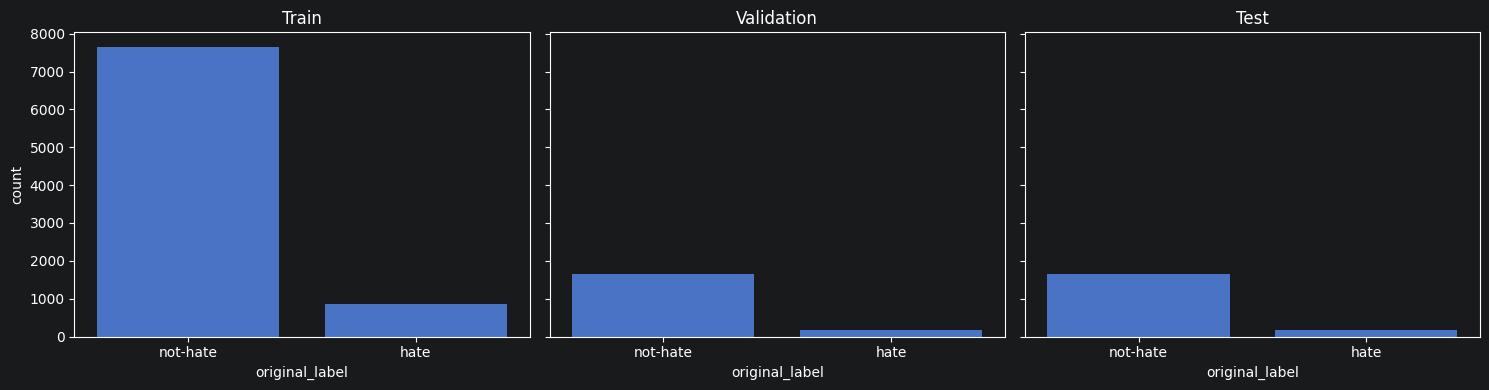

hate
Number of training samples: 8513, not-hate: 7652, hate: 861
Numer of validation samples: 1824, not-hate: 1640, hate: 184
Number of testing samples: 1825, not-hate: 1640, hate: 185


In [56]:
#################################
## Vizuelizacija podele - HATE ##
#################################

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

sns.countplot(x=hateTrainOut, ax=axes[0])
axes[0].set_title("Train")

sns.countplot(x=hateValOut, ax=axes[1])
axes[1].set_title("Validation")

sns.countplot(x=hateTestOut, ax=axes[2])
axes[2].set_title("Test")

plt.tight_layout()
plt.show()

writeStats(hateTrainOut,hateTestOut,hateValOut, "hate")

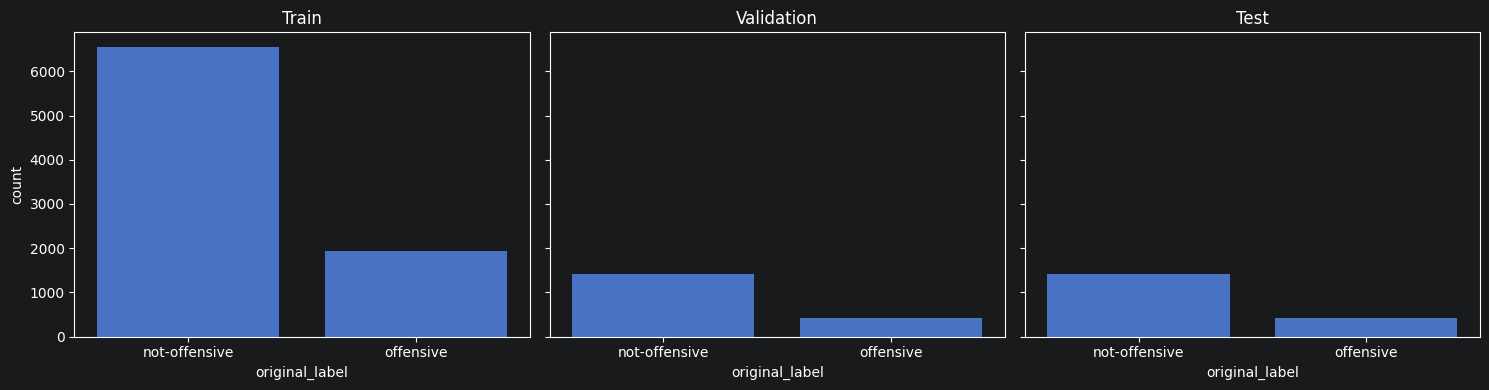

offensive
Number of training samples: 8503, not-offensive: 6556, offensive: 1947
Numer of validation samples: 1822, not-offensive: 1405, offensive: 417
Number of testing samples: 1823, not-offensive: 1406, offensive: 417


In [57]:
######################################
## Vizuelizacija podele - OFFENSIVE ##
######################################

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

sns.countplot(x=offTrainOut, ax=axes[0])
axes[0].set_title("Train")

sns.countplot(x=offValOut, ax=axes[1])
axes[1].set_title("Validation")

sns.countplot(x=offTestOut, ax=axes[2])
axes[2].set_title("Test")

plt.tight_layout()
plt.show()

writeStats(offTrainOut, offTestOut, offValOut, "offensive")

Podela podataka je izvršena.
Sada je na redu fine-tuning modela.

Predložene metode za rešavanje problema loše balansiranosti:
1) Otežinjavanje klasa - klasi koja je manje zastupljena ćemo dodeliti veću težinu (u cilju da loss funkcija njene primerke više penalizuje, čime bi se nedostatak podataka mogao korigovati)
2) Blagi undersampling - umereno proređivanje dominantne klase (npr. do odnosa 3:1 ili 2:1)
3) Oversampling baziran na primeni drugih LLM-ova - neke od metoda poput Back-Translation (Povratni prevod), Zamena sinonimima (WordNet) ili Contextual Word Embeddings

Što se tiče evaluacije, fokus ćemo staviti na analizu F1 skora, možemo razmotriti i Macro-F1 (izgleda korisno i metrika PR-AUC)

In [63]:
#################################
## Priprema za trening         ##
## Računanje tezina po klasama ##
#################################

print("Class weights:")
classWeightsHate = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(hateTrainOut),
    y=hateTrainOut
)
print(f"Not-hate: {classWeightsHate[1]}, Hate: {classWeightsHate[0]}")

classWeightsOff = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(offTrainOut),
    y=offTrainOut
)
print(f"Not-offensive: {classWeightsOff[0]}, Offensive: {classWeightsOff[1]}")

Class weights:
Not-hate: 0.5562598013591218, Hate: 4.9436701509872245
Not-offensive: 0.6484899328859061, Offensive: 2.1836158192090394


**FINE-TUNE  HATE MODEL**
----------------------


In [2]:
##########################################
## Učitavanje i prilagođavanje podataka ##
##########################################

trainDfH = pd.read_csv('trainHate.csv')
valDfH = pd.read_csv('valHate.csv')

labelMap = {'not-hate': 0, 'hate': 1}
trainDfH['label'] = trainDfH['original_label'].map(labelMap)
valDfH['label'] = valDfH['original_label'].map(labelMap)

classWeightsHate = [0.5562598013591218, 4.9436701509872245]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
classWeightsTensorHate = torch.tensor(classWeightsHate, dtype=torch.float).to(device)

In [4]:
################################################################
## Učitavanje, dodatno prilagođavanje i tokenizacija podataka ##
################################################################

modelNameH = f"cardiffnlp/twitter-roberta-base-hate"
tokenizerH = AutoTokenizer.from_pretrained(modelNameH, local_files_only=False, force_download=True)

def tokenizeFunction(examples):
    return tokenizerH(examples['txt_sample'], truncation=True, max_length=128)

trainDatasetHate = Dataset.from_pandas(trainDfH[['txt_sample', 'label']])
valDatasetHate = Dataset.from_pandas(valDfH[['txt_sample', 'label']])

trainDatasetHate = trainDatasetHate.map(tokenizeFunction, batched=True)
valDatasetHate = valDatasetHate.map(tokenizeFunction, batched=True)

dataCollatorH = DataCollatorWithPadding(tokenizer=tokenizerH)

Map: 100%|██████████| 1824/1824 [00:00<00:00, 25284.34 examples/s]


In [27]:
##################################
## Prilagođavanje loss funkcije ##
## za otežinjene klase          ##
##################################

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        lossFct = nn.CrossEntropyLoss(weight=classWeightsTensorOffensive)
        # ovo je korišteno za Hate model
        # lossFct = nn.CrossEntropyLoss(weight=classWeightsTensorHate)

        loss = lossFct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [8]:
#######################
## Računanje metrika ##
#######################

def computeMetrics(evalPred):
    logits, labels = evalPred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    macroF1 = f1_score(labels, predictions, average='macro')

    return {
        'f1_hate': f1,
        'macro_f1': macroF1,
        'precision_hate': precision,
        'recall_hate': recall
    }

In [7]:
#**********************************************************************************************
# Zaobilaženje provere bezbednosti #
transformers.utils.import_utils.check_torch_load_is_safe = lambda: None
for module_name, module in list(sys.modules.items()):
    if module_name.startswith("transformers") and hasattr(module, "check_torch_load_is_safe"):
        setattr(module, "check_torch_load_is_safe", lambda: None)
 #**********************************************************************************************

#############################################################
## Učitavanje modela i priprema hiperparametara treniranja ##
#############################################################

modelH = AutoModelForSequenceClassification.from_pretrained(
    modelNameH,
    num_labels=2,
    ignore_mismatched_sizes=True,
    local_files_only=False,
    force_download=True
)

trainingArgsH = TrainingArguments(
    output_dir='./resultsHate',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=50,
    report_to="none"
)

trainerH = CustomTrainer(
    model=modelH,
    args=trainingArgsH,
    train_dataset=trainDatasetHate,
    eval_dataset=valDatasetHate,
    processing_class=tokenizerH,
    data_collator=dataCollatorH,
    compute_metrics=computeMetrics
)

[transformers] Accessing `check_torch_load_is_safe` from `.models.aria.image_processing_aria`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.aria.image_processing_pil_aria`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.auto.image_processing_auto`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.beit.image_processing_beit`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.beit.image_processing_pil_beit`. Returning `check_torch_lo

In [8]:
#########################
## Aktivacija treninga ##
#########################
trainerH.train()

Epoch,Training Loss,Validation Loss,F1 Hate,Macro F1,Precision Hate,Recall Hate
1,0.485505,0.399061,0.659950,0.809212,0.615023,0.711957
2,0.389443,0.463893,0.647754,0.800776,0.573222,0.744565
3,0.274174,0.738492,0.666667,0.812519,0.610860,0.733696


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]


TrainOutput(global_step=1599, training_loss=0.33517290697461594, metrics={'train_runtime': 95.449, 'train_samples_per_second': 267.567, 'train_steps_per_second': 16.752, 'total_flos': 1420833101714700.0, 'train_loss': 0.33517290697461594, 'epoch': 3.0})

In [9]:
####################
## Čuvanje modela ##
####################

finalFolderFive = "./fineTunedHateModel"
trainerH.save_model(finalFolderFive)
tokenizerH.save_pretrained(finalFolderFive)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.75it/s]


('./fineTunedHateModel/tokenizer_config.json',
 './fineTunedHateModel/tokenizer.json')

In [10]:
######################################
## Aktivacija fine-tunovanog modela ##
######################################
pathFive = "./fineTunedHateModel"

tFive = AutoTokenizer.from_pretrained(pathFive)
mFive = AutoModelForSequenceClassification.from_pretrained(pathFive)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mFive.to(device)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5500.17it/s]


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [14]:
#######################################
## Analiza performansi na test skupu ##
#######################################

labelH = ['not-hate','hate']
hateTestData = pd.read_csv('testHate.csv')
ftResHate = activateModelTwo(hateTestData, tFive, labelH, mFive, 'hate')

In [16]:
#############################
## Čuvanje rezultata testa ##
#############################
ftResHate.to_csv('predikcije_ftHate_modela.csv', index=False)

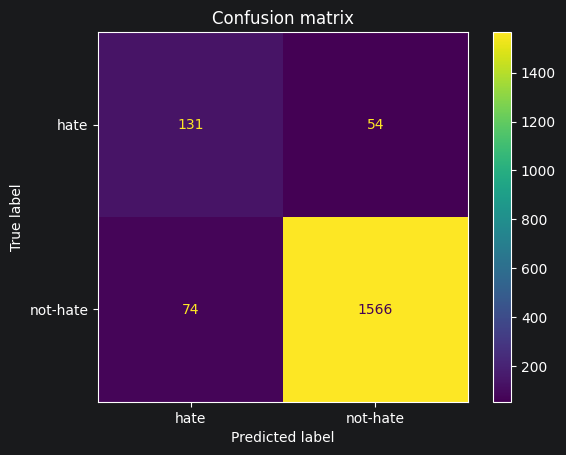

True negative: 1566
False positive: 74
False negative: 54
True positive: 131
Accuracy: 0.930
Precision: 0.639
Recall: 0.708
Specificity: 0.955
F1 - score: 0.672
Balanced accuracy: 0.831


In [7]:
###############################
## Performanse klasifikacije ##
###############################

predikcije_ftHate_model = pd.read_csv('predikcije_ftHate_modela.csv')

cmHate = confusion_matrix(
    predikcije_ftHate_model.original_label,
    predikcije_ftHate_model.pred_label_hate,
    labels=["hate", "not-hate"]
)

TP_h, FN_h, FP_h, TN_h = cmHate.ravel()

ConfusionMatrixDisplay(
    confusion_matrix=cmHate,
    display_labels=["hate", "not-hate"]
).plot()

plt.title('Confusion matrix')
plt.show()

modelMetrics(TN_h, FP_h, FN_h, TP_h)

Dorada:
Uticala je promena funkcije compute_loss.
Labele su sada sredjene, pa je i to dodatno modifikovalo rezultat.

In [16]:

df_hate = pd.read_csv('predikcije_ftHate_modela.csv')


prob_col = [col for col in df_hate.columns if 'prob' in col.lower()][0]
print(f"Pronađena kolona za vjerovatnoću: '{prob_col}'")

pd.set_option('display.max_colwidth', None)

# ==============================================================================
# TIP GRESKE 1: Lažno Pozitivni (False Positives - FP)
# Stvarno je "not-hate", a model je predvidio "hate" (vjerovatnoća > 0.5)
# ==============================================================================
fp_all = df_hate[(df_hate['original_label'] == 'not-hate') & (df_hate['pred_label_hate'] == 'hate')]

# 1a. Ekstremni FP (Model je skoro 100% siguran da je govor mržnje, a zapravo nije)
fp_ekstremni = fp_all.sort_values(by=prob_col, ascending=False).head(4)

# 1b. Granični FP (Model je jedva prešao granicu, vjerovatnoća malo veća od 0.5)
fp_granicni = fp_all.sort_values(by=prob_col, ascending=True).head(4)

# Spajamo ih u jednu listu od 8 primjera
fp_konacno = pd.concat([fp_ekstremni, fp_granicni])


# ==============================================================================
# TIP GRESKE 2: Lažno Negativni (False Negatives - FN)
# Stvarno je "hate", a model je predvidio "not-hate" (vjerovatnoća <= 0.5)
# ==============================================================================
fn_all = df_hate[(df_hate['original_label'] == 'hate') & (df_hate['pred_label_hate'] == 'not-hate')]

# 2a. Ekstremni FN (Model je skoro 100% siguran da NIJE govor mržnje, a zapravo jeste)
fn_ekstremni = fn_all.sort_values(by=prob_col, ascending=True).head(4)

# 2b. Granični FN (Model je zamalo promašio granicu, vjerovatnoća malo manja od 0.5)
fn_granicni = fn_all.sort_values(by=prob_col, ascending=False).head(4)

# Spajamo ih u jednu listu od 8 primjera
fn_konacno = pd.concat([fn_ekstremni, fn_granicni])


# ==============================================================================
# ISPIS REZULTATA
# ==============================================================================

print("\n" + "="*80)
print(" LAŽNO POZITIVNI (Traženo 'not-hate', predviđeno 'hate')")
print(" Prva 4: Najveća sigurnost (blizu 1) | Druga 4: Granični promašaji (blizu 0.5)")
print("="*80)
for idx, row in fp_konacno.iterrows():
    print(f"ID: {row['id']} | Verovatnoća: {row[prob_col]:.4f}")
    print(f"Tekst: {row['txt_sample']}\n{'-'*80}")

print("\n" + "="*80)
print(" LAŽNO NEGATIVNI (Traženo 'hate', predviđeno 'not-hate')")
print(" Prva 4: Najmanja sigurnost (blizu 0) | Druga 4: Granični promašaji (blizu 0.5)")
print("="*80)
for idx, row in fn_konacno.iterrows():
    print(f"ID: {row['id']} | Verovatnoća: {row[prob_col]:.4f}")
    print(f"Tekst: {row['txt_sample']}\n{'-'*80}")

Pronađena kolona za vjerovatnoću: 'prob_hate'

 LAŽNO POZITIVNI (Traženo 'not-hate', predviđeno 'hate')
 Prva 4: Najveća sigurnost (blizu 1) | Druga 4: Granični promašaji (blizu 0.5)
ID: 1562 | Verovatnoća: 0.9992
Tekst: Hmmm... 

So you decide not to answer my question huh?  Is it because I am Japanese?  I knew it!  This site is fucking racist.  You are a god dam motherfucking racist piece of shit!  All you Japanese hating motherfuckers should go to hell.  Especially the Americans!.  They should go to hell for killing all my people in WW2.  Tell me why you are a racist you son of a bitch?  I am going to report this to the administrators to get you ass blocked!
--------------------------------------------------------------------------------
ID: 1358 | Verovatnoća: 0.9992
Tekst: COMPLAIN & AND MORE COMPLAINS THATS WHAT U'RE GOOD FOR !
FUCKIN IDIOT !
If I happen to know who u are I'll wallop the shit out of u damn bastard !
----------------------------------------------------------------

**FINE-TUNE OFFENSIVE MODEL**
------------

In [3]:
##########################################
## Učitavanje i prilagođavanje podataka ##
##########################################

trainDfOF = pd.read_csv('trainOffensive.csv')
valDfOF = pd.read_csv('vallOffensive.csv')

labelMap = {'not-offensive': 0, 'offensive': 1}
trainDfOF['label'] = trainDfOF['original_label'].map(labelMap)
valDfOF['label'] = valDfOF['original_label'].map(labelMap)

classWeightsOffensive = [0.6484899328859061, 2.1836158192090394]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
classWeightsTensorOffensive = torch.tensor(classWeightsOffensive, dtype=torch.float).to(device)

In [4]:
################################################################
## Učitavanje, dodatno prilagođavanje i tokenizacija podataka ##
################################################################

modelNameO = f"cardiffnlp/twitter-roberta-base-offensive"
tokenizerO = AutoTokenizer.from_pretrained(modelNameO, local_files_only=False, force_download=True)

def tokenizeFunction(examples):
    return tokenizerO(examples['txt_sample'], truncation=True, max_length=128)

trainDatasetOffensive = Dataset.from_pandas(trainDfOF[['txt_sample', 'label']])
valDatasetOffensive = Dataset.from_pandas(valDfOF[['txt_sample', 'label']])

trainDatasetOffensive = trainDatasetOffensive.map(tokenizeFunction, batched=True)
valDatasetOffensive = valDatasetOffensive.map(tokenizeFunction, batched=True)

dataCollatorO = DataCollatorWithPadding(tokenizer=tokenizerO)

Map: 100%|██████████| 1822/1822 [00:00<00:00, 25793.68 examples/s]


In [29]:
#**********************************************************************************************
# Zaobilaženje provere bezbednosti #
transformers.utils.import_utils.check_torch_load_is_safe = lambda: None
for module_name, module in list(sys.modules.items()):
    if module_name.startswith("transformers") and hasattr(module, "check_torch_load_is_safe"):
        setattr(module, "check_torch_load_is_safe", lambda: None)
 #**********************************************************************************************

#############################################################
## Učitavanje modela i priprema hiperparametara treniranja ##
#############################################################

modelO = AutoModelForSequenceClassification.from_pretrained(
    modelNameO,
    num_labels=2,
    ignore_mismatched_sizes=True,
    local_files_only=False,
    force_download=True
)

trainingArgsO = TrainingArguments(
    output_dir='./resultsOffensive',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=50,
    report_to="none"
)

trainerO = CustomTrainer(
    model=modelO,
    args=trainingArgsO,
    train_dataset=trainDatasetOffensive,
    eval_dataset=valDatasetOffensive,
    processing_class=tokenizerO,
    data_collator=dataCollatorO,
    compute_metrics=computeMetrics)

[transformers] Accessing `check_torch_load_is_safe` from `.models.aria.image_processing_aria`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.aria.image_processing_pil_aria`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.auto.image_processing_auto`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.beit.image_processing_beit`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.beit.image_processing_pil_beit`. Returning `check_torch_lo

In [30]:
#########################
## Aktivacija treninga ##
#########################
trainerO.train()

Epoch,Training Loss,Validation Loss,F1 Hate,Macro F1,Precision Hate,Recall Hate
1,0.451498,0.411598,0.673935,0.774538,0.574324,0.815348
2,0.319563,0.428924,0.687129,0.783580,0.585160,0.832134
3,0.180856,0.528733,0.695279,0.795280,0.629126,0.776978


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.96it/s]


TrainOutput(global_step=1596, training_loss=0.3417240969818039, metrics={'train_runtime': 89.3773, 'train_samples_per_second': 285.408, 'train_steps_per_second': 17.857, 'total_flos': 1413930547621740.0, 'train_loss': 0.3417240969818039, 'epoch': 3.0})

In [31]:
####################
## Čuvanje modela ##
####################

finalFolderO = "./fineTunedOffensiveModel"
trainerO.save_model(finalFolderO)
tokenizerO.save_pretrained(finalFolderO)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.93it/s]


('./fineTunedOffensiveModel/tokenizer_config.json',
 './fineTunedOffensiveModel/tokenizer.json')

In [32]:
######################################
## Aktivacija fine-tunovanog modela ##
######################################
pathO = "./fineTunedOffensiveModel"

tO = AutoTokenizer.from_pretrained(pathO)
mO = AutoModelForSequenceClassification.from_pretrained(pathO)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mO.to(device)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7483.58it/s]


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [33]:
#######################################
## Analiza performansi na test skupu ##
#######################################

labelO= ['not-offensive','offensive']
offensiveTestData = pd.read_csv('testOffensive.csv')
ftResOffensive = activateModelTwo(offensiveTestData, tO, labelO, mO, 'offensive')

In [34]:
#############################
## Čuvanje rezultata testa ##
#############################
ftResOffensive.to_csv('predikcije_ftOffensive_modela.csv', index=False)

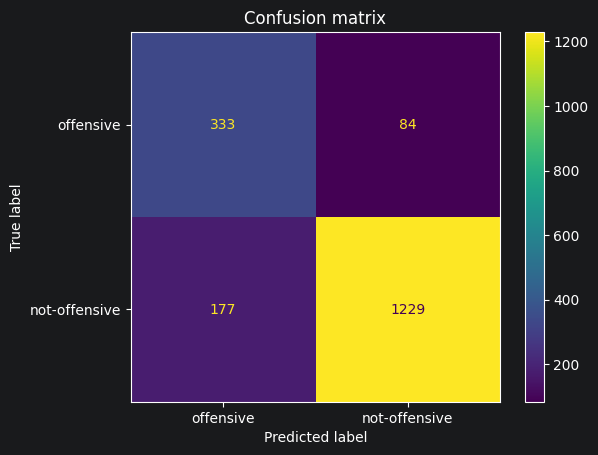

True negative: 1229
False positive: 177
False negative: 84
True positive: 333
Accuracy: 0.857
Precision: 0.653
Recall: 0.799
Specificity: 0.874
F1 - score: 0.718
Balanced accuracy: 0.836


In [8]:
###############################
## Performanse klasifikacije ##
###############################

predikcije_ftOffensive_model = pd.read_csv('predikcije_ftOffensive_modela.csv')

cmOffensive = confusion_matrix(
    predikcije_ftOffensive_model.original_label,
    predikcije_ftOffensive_model.pred_label_offensive,
    labels=["offensive", "not-offensive"]
)

TP_o, FN_o, FP_o, TN_o = cmOffensive.ravel()

ConfusionMatrixDisplay(
    confusion_matrix=cmOffensive,
    display_labels=["offensive", "not-offensive"]
).plot()

plt.title('Confusion matrix')
plt.show()

modelMetrics(TN_o, FP_o, FN_o, TP_o)

In [11]:
# Učitavanje podataka
df_off = pd.read_csv('predikcije_ftOffensive_modela.csv')

# AUTOMATSKO PRONALAŽENJE KOLONE: Tražimo kolonu koja u svom imenu sadrži 'prob'
prob_col = [col for col in df_off.columns if 'prob' in col.lower()][0]
print(f"Pronađena kolona za vjerovatnoću: '{prob_col}'")

# Postavljanje maksimalne širine kolone da ti se tekst tvita vidi cijeli pri ispisu
pd.set_option('display.max_colwidth', None)

# ==============================================================================
# TIP GRESKE 1: Lažno Pozitivni (False Positives - FP)
# Stvarno je "not-offensive", a model je predvidio "offensive" (vjerovatnoća > 0.5)
# ==============================================================================
fp_all = df_off[(df_off['original_label'] == 'not-offensive') & (df_off['pred_label_offensive'] == 'offensive')]

# 1a. Ekstremni FP (Model je skoro 100% siguran da je uvredljivo, a zapravo nije)
fp_ekstremni = fp_all.sort_values(by=prob_col, ascending=False).head(4)

# 1b. Granični FP (Model je jedva prešao granicu, vjerovatnoća malo veća od 0.5)
fp_granicni = fp_all.sort_values(by=prob_col, ascending=True).head(4)

# Spajamo ih u jednu listu od 8 primjera
fp_konacno = pd.concat([fp_ekstremni, fp_granicni])


# ==============================================================================
# TIP GRESKE 2: Lažno Negativni (False Negatives - FN)
# Stvarno je "offensive", a model je predvidio "not-offensive" (vjerovatnoća <= 0.5)
# ==============================================================================
fn_all = df_off[(df_off['original_label'] == 'offensive') & (df_off['pred_label_offensive'] == 'not-offensive')]

# 2a. Ekstremni FN (Model je skoro 100% siguran da NIJE uvredljivo, a zapravo jeste)
fn_ekstremni = fn_all.sort_values(by=prob_col, ascending=True).head(4)

# 2b. Granični FN (Model je zamalo promašio granicu, vjerovatnoća malo manja od 0.5)
fn_granicni = fn_all.sort_values(by=prob_col, ascending=False).head(4)

# Spajamo ih u jednu listu od 8 primjera
fn_konacno = pd.concat([fn_ekstremni, fn_granicni])


# ==============================================================================
# ISPIS REZULTATA
# ==============================================================================

print("\n" + "="*80)
print(" LAŽNO POZITIVNI (Traženo 'not-offensive', predviđeno 'offensive')")
print(" Prva 4: Najveća sigurnost (blizu 1) | Druga 4: Granični promašaji (blizu 0.5)")
print("="*80)
for idx, row in fp_konacno.iterrows():
    print(f"ID: {row['id']} | Vjerovatnoća: {row[prob_col]:.4f}")
    print(f"Tekst: {row['txt_sample']}\n{'-'*80}")

print("\n" + "="*80)
print(" LAŽNO NEGATIVNI (Traženo 'offensive', predviđeno 'not-offensive')")
print(" Prva 4: Najmanja sigurnost (blizu 0) | Druga 4: Granični promašaji (blizu 0.5)")
print("="*80)
for idx, row in fn_konacno.iterrows():
    print(f"ID: {row['id']} | Verovatnoća: {row[prob_col]:.4f}")
    print(f"Tekst: {row['txt_sample']}\n{'-'*80}")

Pronađena kolona za vjerovatnoću: 'prob_offensive'

 LAŽNO POZITIVNI (Traženo 'not-offensive', predviđeno 'offensive')
 Prva 4: Najveća sigurnost (blizu 1) | Druga 4: Granični promašaji (blizu 0.5)
ID: 646 | Vjerovatnoća: 0.9950
Tekst: Bullshit. Go to hell, you fucking vandal.
--------------------------------------------------------------------------------
ID: 1071 | Vjerovatnoća: 0.9948
Tekst: Holy <b>shit!!!<\/b> #ufc196
--------------------------------------------------------------------------------
ID: 675 | Vjerovatnoća: 0.9947
Tekst: Sick POV
What the hell? 
User:Izady is a sick fuck:

It should be noted that the conditions in which individuals died varies from site to site. The people that were buried in these graves are believed to have been members of the Kurdish population which was in support of Iranian occupancy of Iraq at the time of their death (circa 1980's) 'and who deserved to die in the hands of patriotic Sunni Arabs of Iraq'. The legitimacy of claims of atrocity are 

In [ ]:
predikcijeFiveModel = pd.read_csv("predikcije_fiveClasses_modela.csv")

labelsFive = ["Hate Speech", "Derogatory", "Profanity", "Trolling", "Normal"]

cmFive = confusion_matrix(
    predikcijeFiveModel.original_label,
    predikcijeFiveModel.pred_label_fiveClasses,
    labels=labelsFive,
)

print("--- Classification Report ---")
print(
    classification_report(
        predikcijeFiveModel.original_label,
        predikcijeFiveModel.pred_label_fiveClasses,
        labels=labelsFive,
    )
)

plt.figure(figsize=(10, 8))
display = ConfusionMatrixDisplay(confusion_matrix=cmFive, display_labels=labelsFive)
display.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - 5 Classes")
plt.tight_layout()
plt.show()

**Five class problem (original problem)**
---------------------------

In [4]:
#########################
## Predobrada dataseta ##
#########################

dataFive = preprocessDataset(data, 'Sample','Majority_label')

Initial number of rows: 12490
After removing exact duplicates: 12277 (Removed: 213)
After removing conflicting samples: 12123 (Conflicting removed: 154)
--- Total retained: 12123 rows (97.06% of original dataset) ---


In [8]:
########################################
## Podela podatadataka train\val\test ##
########################################

randomState = 42

fiveTrainSample, fiveTestSample, fiveTrainOut, fiveTestOut =  train_test_split(dataFive['Sample'], dataFive['Majority_label'], test_size=0.3, shuffle=True, random_state=randomState, stratify=dataFive['Majority_label'])

fiveValSample, fiveTestSample, fiveValOut, fiveTestOut = train_test_split(fiveTestSample, fiveTestOut, test_size=0.5, shuffle=True, random_state=randomState, stratify=fiveTestOut)

--- Class counts for 'Majority_label' ---
Majority_label
Normal         5005
Trolling       4352
Profanity      1551
Derogatory      792
Hate Speech     423
Name: count, dtype: int64
----------------------------------------
Total unique classes: 5



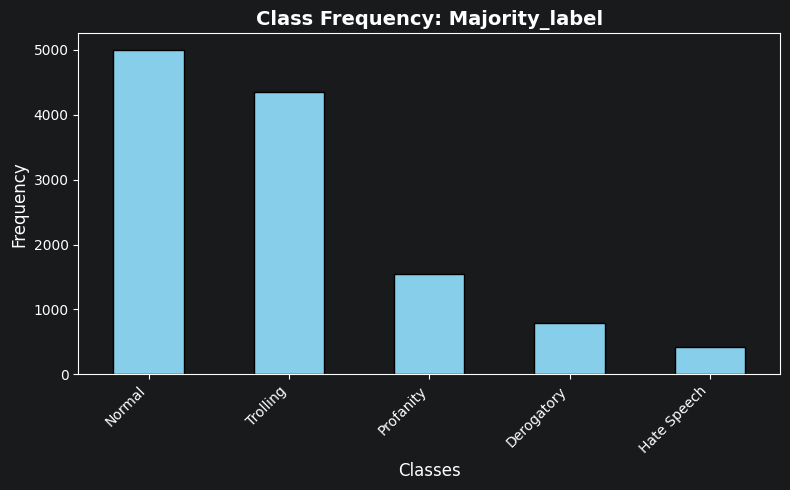

In [16]:
################################################
## Funkcija koaja anlizira distribuciju klasa ##
################################################

def analyzeClassDistribution(dataFrame, columnName):
    uniqueClasses = dataFrame[columnName].dropna().unique()
    classCounts = dataFrame[columnName].value_counts()

    print(f"--- Class counts for '{columnName}' ---")
    print(classCounts)
    print("-" * 40)
    print(f"Total unique classes: {len(uniqueClasses)}\n")

    plt.figure(figsize=(8, 5))
    classCounts.plot(kind="bar", color="skyblue", edgecolor="black")

    plt.title(f"Class Frequency: {columnName}", fontsize=14, fontweight="bold")
    plt.xlabel("Classes", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

analyzeClassDistribution(dataFive,'Majority_label')

In [15]:
####################
## Čuvanje podele ##
####################


trainToSaveFive = pd.DataFrame({
    'id': fiveTrainSample.index,
    'txt_sample': fiveTrainSample.values,
    'original_label': fiveTrainOut.values
}).to_csv('trainFive.csv', index=False)

testToSaveHate = pd.DataFrame({
    'id': fiveTestSample.index,
    'txt_sample': fiveTestSample.values,
    'original_label': fiveTestOut.values
}).to_csv('testFive.csv', index=False)

valToSaveHate = pd.DataFrame({
    'id': fiveValSample.index,
    'txt_sample': fiveValSample.values,
    'original_label': fiveValOut.values
}).to_csv('valFive.csv', index=False)



In [17]:
#######################
## Učitavanje podele ##
#######################

dfFiveTrain = pd.read_csv('trainFive.csv', index_col=False)
dfFiveTest = pd.read_csv('testFive.csv', index_col=False)
dfFiveVal = pd.read_csv('valFive.csv', index_col=False)

******************* T R A I N ********************
--- Class counts for 'original_label' ---
original_label
Normal         3504
Trolling       3046
Profanity      1086
Derogatory      554
Hate Speech     296
Name: count, dtype: int64
----------------------------------------
Total unique classes: 5



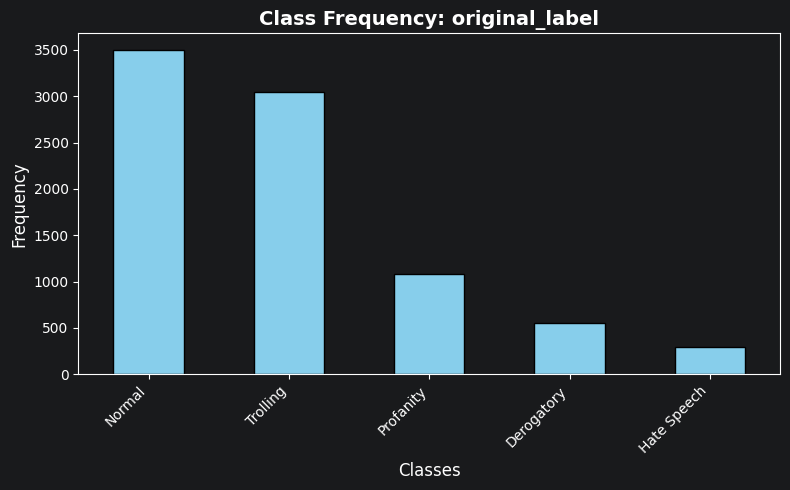

************* V A L I D A T I O N ****************
--- Class counts for 'original_label' ---
original_label
Normal         750
Trolling       653
Profanity      232
Derogatory     119
Hate Speech     64
Name: count, dtype: int64
----------------------------------------
Total unique classes: 5



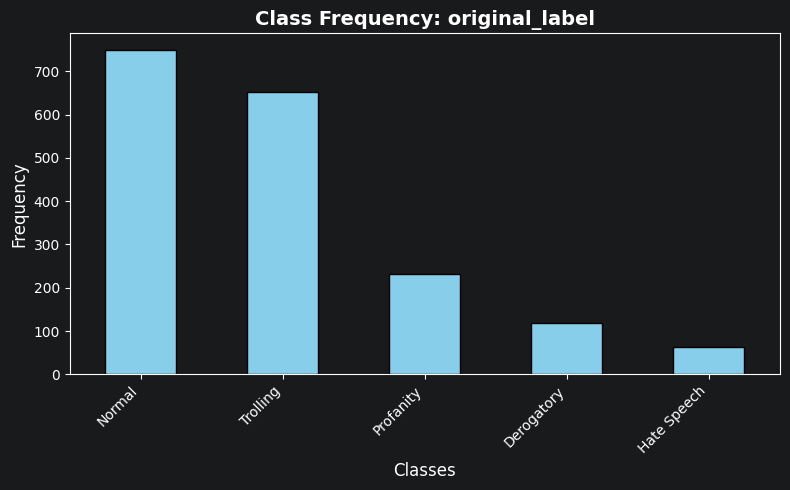

******************** T E S T **********************
--- Class counts for 'original_label' ---
original_label
Normal         751
Trolling       653
Profanity      233
Derogatory     119
Hate Speech     63
Name: count, dtype: int64
----------------------------------------
Total unique classes: 5



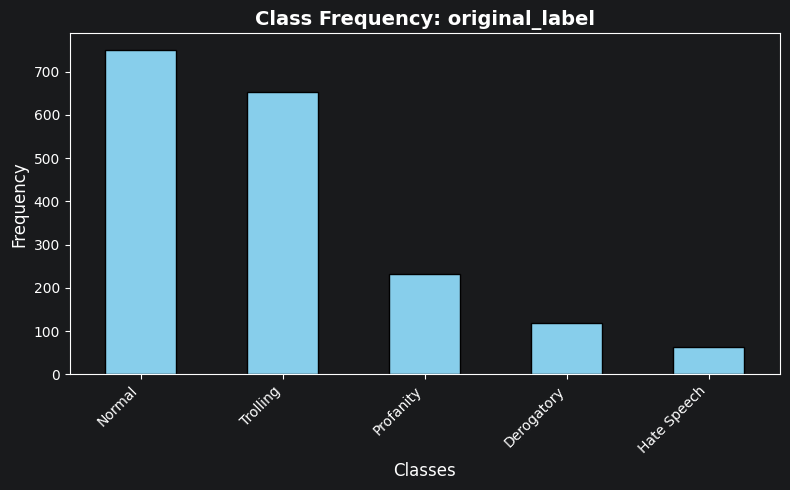

In [20]:
#######################
## Statistika podele ##
#######################

print("******************* T R A I N ********************")
analyzeClassDistribution(dfFiveTrain,'original_label')
print("************* V A L I D A T I O N ****************")
analyzeClassDistribution(dfFiveVal,'original_label')
print("******************** T E S T **********************")
analyzeClassDistribution(dfFiveTest,'original_label')

In [28]:
#################################
## Računanje težina po klasama ##
#################################

print("Class weights:")
classWeightsFive = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(dfFiveTrain.original_label),
    y=dfFiveTrain.original_label
)

classWeightsFiveDict = {'Hate Speech':classWeightsFive[1],
                        'Derogatory':classWeightsFive[0],
                        'Profanity':classWeightsFive[3],
                        'Trolling':classWeightsFive[4],
                        'Normal':classWeightsFive[2]}


print("class --> weight")
for key in classWeightsFiveDict.keys():
    print(f"{key} --> {classWeightsFiveDict[key]}")

Class weights:
class --> weight
Hate Speech --> 5.7337837837837835
Derogatory --> 3.063537906137184
Profanity --> 1.5627992633517496
Trolling --> 0.5571897570584373
Normal --> 0.4843607305936073


In [29]:
###################################
## Dodatna priprema za fine-tune ##
###################################

labelMapFive = {
    "Hate Speech": 0,
    "Derogatory": 1,
    "Profanity": 2,
    "Trolling": 3,
    "Normal": 4,
}

dfFiveTrain["label"] = dfFiveTrain["original_label"].map(labelMapFive)
dfFiveVal["label"] = dfFiveVal["original_label"].map(labelMapFive)
dfFiveTest["label"] = dfFiveTest["original_label"].map(labelMapFive)

classWeightsFive = [
    5.7337837837837835,
    3.063537906137184,
    1.5627992633517496,
    0.5571897570584373,
    0.4843607305936073,
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classWeightsTensorFive = torch.tensor(classWeightsFive, dtype=torch.float).to(device)

In [30]:
###############################################################
## Učitavanje tokenizatora i modela                          ##
## Prilagođavanje podataka
## Koristimo standardni roberta-base model sa Hugging Face-a ##
###############################################################

modelNameFive = "roberta-base"
tokenizerFive = AutoTokenizer.from_pretrained(modelNameFive, local_files_only=False, force_download=True)

def tokenizeFunctionFive(examples):
    return tokenizerFive(examples['txt_sample'], truncation=True, max_length=128)

trainDatasetFive = Dataset.from_pandas(dfFiveTrain[['txt_sample', 'label']])
valDatasetFive = Dataset.from_pandas(dfFiveVal[['txt_sample', 'label']])
testDatasetFive = Dataset.from_pandas(dfFiveTest[['txt_sample', 'label']])

trainDatasetFive = trainDatasetFive.map(tokenizeFunctionFive, batched=True)
valDatasetFive = valDatasetFive.map(tokenizeFunctionFive, batched=True)
testDatasetFive = testDatasetFive.map(tokenizeFunctionFive, batched=True)

dataCollatorFive = DataCollatorWithPadding(tokenizer=tokenizerFive)

Map: 100%|██████████| 1819/1819 [00:00<00:00, 10223.77 examples/s]


In [31]:
##################################
## Prilagođavanje loss funkcije ##
## Višeklasna klasifikacija     ##
##################################

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        modelInputs = {k: v for k, v in inputs.items() if k != "labels"}

        outputs = model(**modelInputs)
        logits = outputs.get("logits")

        lossFct = nn.CrossEntropyLoss(weight=classWeightsTensorFive)
        loss = lossFct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        if num_items_in_batch is not None and num_items_in_batch > 0:
            loss = loss / num_items_in_batch

        return (loss, outputs) if return_outputs else loss

In [35]:
#######################
## Računanje metrika ##
#######################


def computeMetrics(evalPred):
    logits, labels = evalPred
    predictions = np.argmax(logits, axis=1)

    macroPrecision, macroRecall, macroF1, _ = precision_recall_fscore_support(labels, predictions, average='macro')

    return {
        'macroPrecision': macroPrecision,
        'macroRecall': macroRecall,
        'macroF1': macroF1
    }

In [37]:
#**********************************************************************************************
# Zaobilaženje provere bezbednosti #
transformers.utils.import_utils.check_torch_load_is_safe = lambda: None
for module_name, module in list(sys.modules.items()):
    if module_name.startswith("transformers") and hasattr(module, "check_torch_load_is_safe"):
        setattr(module, "check_torch_load_is_safe", lambda: None)
 #**********************************************************************************************

#############################################################
## Učitavanje modela i priprema hiperparametara treniranja ##
#############################################################

modelFive = AutoModelForSequenceClassification.from_pretrained(
    modelNameFive,
    num_labels=5,
    ignore_mismatched_sizes=True,
    local_files_only=False,
    force_download=True
)

trainingArgsFive = TrainingArguments(
    output_dir='./resultsFive',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macroF1",
    logging_steps=50,
    report_to="none"
)

trainerFive = CustomTrainer(
    model=modelFive,
    args=trainingArgsFive,
    train_dataset=trainDatasetFive,
    eval_dataset=valDatasetFive,
    processing_class=tokenizerFive,
    data_collator=dataCollatorFive,
    compute_metrics=computeMetrics
)

[transformers] Accessing `check_torch_load_is_safe` from `.models.aria.image_processing_aria`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.aria.image_processing_pil_aria`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.auto.image_processing_auto`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.beit.image_processing_beit`. Returning `check_torch_load_is_safe` instead. Behavior may be different and this alias will be removed in future versions.
[transformers] Accessing `check_torch_load_is_safe` from `.models.beit.image_processing_pil_beit`. Returning `check_torch_lo

In [38]:
#########################
## Aktivacija treninga ##
#########################
trainerFive.train()

Epoch,Training Loss,Validation Loss,Macroprecision,Macrorecall,Macrof1
1,0.053086,0.051329,0.596233,0.678150,0.615015
2,0.037831,0.050164,0.609491,0.693182,0.630277
3,0.029410,0.054756,0.658083,0.713887,0.673555


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.66it/s]


TrainOutput(global_step=1593, training_loss=0.044200206656015976, metrics={'train_runtime': 93.2202, 'train_samples_per_second': 273.095, 'train_steps_per_second': 17.089, 'total_flos': 1419772135267572.0, 'train_loss': 0.044200206656015976, 'epoch': 3.0})

In [40]:
####################
## Čuvanje modela ##
####################

finalFolderFive = "./fineTunedFiveModel"
trainerFive.save_model(finalFolderFive)
tokenizerFive.save_pretrained(finalFolderFive)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.78it/s]


('./fineTunedFiveModel/tokenizer_config.json',
 './fineTunedFiveModel/tokenizer.json')

In [41]:
######################################
## Aktivacija fine-tunovanog modela ##
######################################
pathFive = "./fineTunedFiveModel"

tFive = AutoTokenizer.from_pretrained(pathFive)
mFive= AutoModelForSequenceClassification.from_pretrained(pathFive)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mFive.to(device)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6802.07it/s]


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [45]:
##########################################
## Funkcija za evaluacija na test skupu ##
##########################################

def activateModelFive(data, tokenizer, labelsList, model, taskType):
    result = pd.DataFrame(columns=["id", "txt_sample", "original_label",f"pred_label_{taskType}",f"prob_{taskType}",])

    model.to(device)
    model.eval()

    i = 0
    for row in data.itertuples():
        rowId = i

        try:
            originalLabel = row.Majority_label
        except (AttributeError, KeyError):
            originalLabel = row.original_label

        try:
            sample = row.Sample
        except (AttributeError, KeyError):
            sample = row.txt_sample

        processedText = preprocess(sample) if "preprocess" in globals() else sample

        encodedInput = tokenizer(
            processedText,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128,
        ).to(device)

        with torch.no_grad():
            output = model(**encodedInput)
            logits = output.logits.squeeze(0).cpu().numpy()

        scores = softmax(logits)
        predictedIndex = np.argmax(scores)

        predLabel = labelsList[predictedIndex]
        prob = scores[predictedIndex]

        result.loc[rowId] = [rowId, sample, originalLabel, predLabel, prob]
        i += 1

    return result

In [46]:
###########################
## Primena na test skupu ##
###########################

labelsFive = ["Hate Speech", "Derogatory", "Profanity", "Trolling", "Normal"]
ftResFive = activateModelFive(dfFiveTest, tokenizerFive, labelsFive, modelFive, "fiveClasses")

In [47]:
#####################################
## Čuvanje rezultata na test skupu ##
#####################################

ftResFive.to_csv('predikcije_ftFive_modela.csv', index=False)

--- Classification Report ---
              precision    recall  f1-score   support

 Hate Speech       0.56      0.63      0.60        63
  Derogatory       0.35      0.60      0.44       119
   Profanity       0.67      0.81      0.73       233
    Trolling       0.78      0.63      0.70       653
      Normal       0.92      0.89      0.91       751

    accuracy                           0.76      1819
   macro avg       0.66      0.71      0.67      1819
weighted avg       0.79      0.76      0.77      1819



<Figure size 1000x800 with 0 Axes>

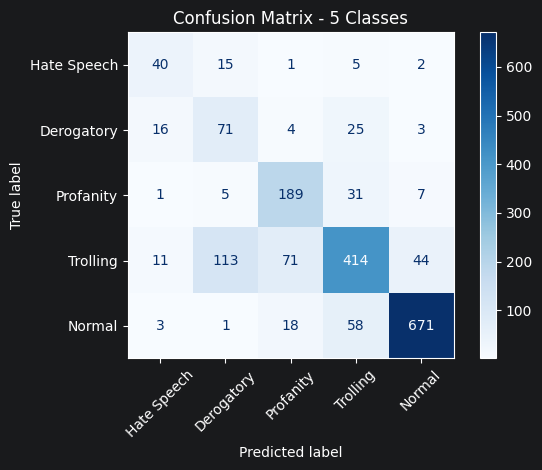

In [50]:
#######################################
## Analiza performansi na test skupu ##
#######################################

predikcijeFiveModel = pd.read_csv('predikcije_ftFive_modela.csv')

cmFive = confusion_matrix(
    predikcijeFiveModel.original_label,
    predikcijeFiveModel.pred_label_fiveClasses,
    labels=labelsFive,
)

print("--- Classification Report ---")
print(
    classification_report(
        predikcijeFiveModel.original_label,
        predikcijeFiveModel.pred_label_fiveClasses,
        labels=labelsFive,
    )
)

plt.figure(figsize=(10, 8))
display = ConfusionMatrixDisplay(confusion_matrix=cmFive, display_labels=labelsFive)
display.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - 5 Classes")
plt.tight_layout()
plt.show()

In [51]:
###################################
## Računanje f1-score po klasama ##
###################################

stvarneLabele = predikcijeFiveModel.original_label
predvidjeneLabele = predikcijeFiveModel.pred_label_fiveClasses

macroF1 = f1_score(stvarneLabele, predvidjeneLabele, average='macro')
f1PoKlasama = f1_score(stvarneLabele, predvidjeneLabele, average=None)
precisionPoKlasama = precision_score(stvarneLabele, predvidjeneLabele, average=None)
recallPoKlasama = recall_score(stvarneLabele, predvidjeneLabele, average=None)

print(f"Macro F1 Score: {macroF1:.4f}")
print(f"F1 po klasama (redom): {f1PoKlasama}")
print(f"Precision po klasama (redom): {precisionPoKlasama}")
print(f"Recall po klasama (redom): {recallPoKlasama}")

Macro F1 Score: 0.6748
F1 po klasama (redom): [0.4382716  0.59701493 0.90798376 0.73255814 0.69814503]


In [17]:
import pandas as pd


df_five = pd.read_csv('predikcije_ftFive_modela.csv')

pred_col = [col for col in df_five.columns if ('pred' in col.lower() or 'label' in col.lower()) and col not in ['original_label', 'prob_fiveClasses']][0]
prob_col = 'prob_fiveClasses'

print(f"Detected True Class column: 'original_label'")
print(f"Detected Predicted Class column: '{pred_col}'")
print(f"Detected Probability column: '{prob_col}'\n")

pd.set_option('display.max_colwidth', None)


analysis_pairs = [
    ("Trolling", "Derogatory"),
    ("Trolling", "Profanity"),
    ("Trolling", "Normal"),
    ("Normal", "Trolling"),
    ("Profanity", "Trolling")
]

print("="*90)
print(" ERROR ANALYSIS (5 CLASSES) - Top 3 Examples with Highest Predicted Probability")
print("="*90)

for true_class, pred_class in analysis_pairs:
    condition = (df_five['original_label'] == true_class) & (df_five[pred_col] == pred_class)
    df_filtered = df_five[condition]

    top_3 = df_filtered.sort_values(by=prob_col, ascending=False).head(3)

    print(f"\n>>> PAIR: [True: {true_class}] / [Predicted: {pred_class}] (Total errors found: {len(df_filtered)})")
    print("-" * 90)

    if top_3.empty:
        print("No examples found for this specific error combination.")
    else:
        for idx, row in top_3.iterrows():
            print(f"ID: {row['id']} | Predicted Probability: {row[prob_col]:.4f}")
            print(f"Text: {row['txt_sample']}")
            print("." * 50)

Detected True Class column: 'original_label'
Detected Predicted Class column: 'pred_label_fiveClasses'
Detected Probability column: 'prob_fiveClasses'

 ERROR ANALYSIS (5 CLASSES) - Top 3 Examples with Highest Predicted Probability

>>> PAIR: [True: Trolling] / [Predicted: Derogatory] (Total errors found: 113)
------------------------------------------------------------------------------------------
ID: 1559 | Predicted Probability: 0.9552
Text: because I am a huge faggot
..................................................
ID: 1137 | Predicted Probability: 0.9487
Text: Screw you motherfucker!!! 80.220.6.195
..................................................
ID: 577 | Predicted Probability: 0.9422
Text: Bad bitch pussy aquafina call her Crystalina
..................................................

>>> PAIR: [True: Trolling] / [Predicted: Profanity] (Total errors found: 71)
------------------------------------------------------------------------------------------
ID: 247 | Predicted Prob

--------------------------------------
Provera aktivnosti GPU jedinice

In [21]:
print("CUDA dostupna:", torch.cuda.is_available())
print("Verzija Toraha:", torch.__version__)

CUDA dostupna: True
Verzija Toraha: 2.5.1+cu121
